# The MBRA global nonlocal dispersive optical potential

This notebook demonstrates `jitr.optical_potentials.mbra` — the global
*nonlocal and dispersive* neutron optical model of
[B. Morillon, G. Blanchon, P. Romain and H. F. Arellano,
arXiv:2403.05843 (2024)](https://arxiv.org/abs/2403.05843)
(called "NLD" in the paper), valid for $16 \le A \le 209$ and incident
energies from 1 keV to 250 MeV.

The model is a dispersive extension of the Perey–Buck potential: the real
volume, real+imaginary surface, and real+imaginary spin-orbit terms all share
a Gaussian nonlocality form factor of range $\beta = 0.915$ fm, while the
imaginary volume term is local. The energy dependence of the real terms is
generated entirely by dispersion relations acting on the imaginary depths.

We reproduce, for $n + {}^{208}$Pb (and $^{40}$Ca, $^{89}$Y where shown in
the paper):

1. **the nonlocal partial-wave kernels** $\nu_l(r, r')$ (paper Eq. 7),
2. **the depths and dispersive corrections vs energy** (paper Fig. 3),
3. **differential elastic cross sections** (paper Fig. 6), and
4. **the total cross section from 0.3 to 250 MeV** (paper Fig. 5),

with EXFOR data overlaid in (3) and (4). Along the way this exercises two
headline capabilities of the `jitr.xs` workspaces: $\ell$-dependent
nonlocal kernels (`l_dependent=True`) and energy-grid vectorization.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import jitr
from jitr.optical_potentials import mbra

In [2]:
neutron = (1, 0)
target = (208, 82)
reaction = jitr.reactions.Reaction(target=target, projectile=neutron, process="EL")
# the paper's E_F = -[S_n(Z, N) + S_n(Z, N+1)]/2, from jitr's mass tables
print(f"E_F(208Pb) = {reaction.Ef:.3f} MeV")

E_F(208Pb) = -5.653 MeV


In [3]:
def mbra_terms(workspace, reaction, kinematics):
    """Assemble the three MBRA terms on a workspace's grid, stacked over
    the energy grid: l-dependent nonlocal central, local central, and
    l-dependent nonlocal spin-orbit. One vectorized call evaluates all
    depths per energy grid and builds the Perey-Buck kernel once, shared
    between the two nonlocal terms."""
    return mbra.assemble_terms(
        workspace.radial_grid(),
        np.arange(workspace.lmax + 1),
        (reaction.projectile.A, reaction.projectile.Z),
        (reaction.target.A, reaction.target.Z),
        kinematics.Elab,
        reaction.Ef,
    )


def mbra_interaction(workspace, reaction, kinematics):
    """Compose the full MBRA interaction for a workspace."""
    K_nl, W_loc, K_so = mbra_terms(workspace, reaction, kinematics)
    return (
        workspace.central(K_nl, l_dependent=True, energy_dependent=True)
        + workspace.central(W_loc, energy_dependent=True)
        + workspace.spin_orbit(K_so, l_dependent=True, energy_dependent=True)
    )

## 1. The nonlocal kernels

In partial waves the Perey–Buck form $V(\mathbf{r}, \mathbf{r}') =
U\!\left(\tfrac{r+r'}{2}\right) H(|\mathbf{r}-\mathbf{r}'|)$ becomes
(paper Eq. 7)

$$\nu_l(r, r') = \frac{4 r r'}{\sqrt{\pi}\beta^3}\,
  U\!\left(\frac{r+r'}{2}\right)
  e^{-(r^2+r'^2)/\beta^2}\, i_l\!\left(\frac{2 r r'}{\beta^2}\right),$$

an intrinsically $\ell$-dependent nonlocal kernel: the modified spherical
Bessel factor suppresses the kernel near the origin more strongly for higher
$\ell$. The kernel is concentrated within $\sim\beta$ of the diagonal.

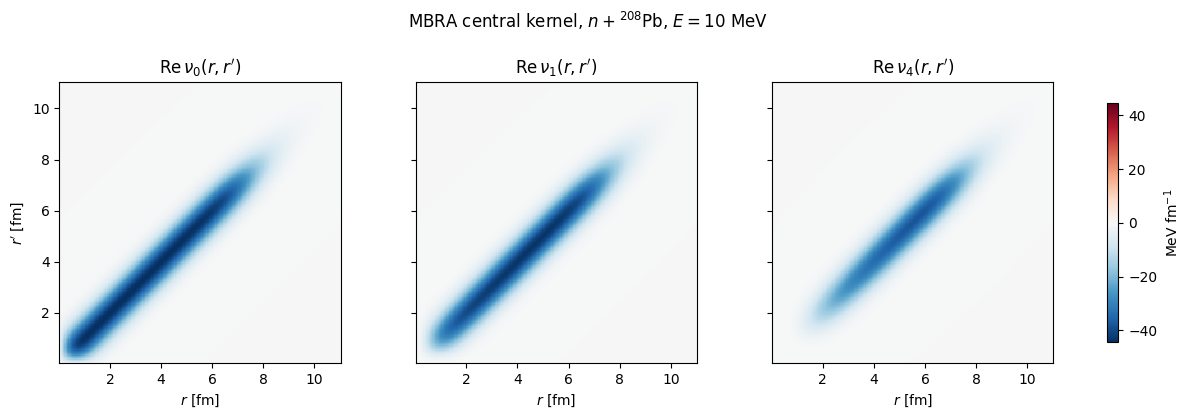

In [4]:
r_plot = np.linspace(0.05, 11.0, 220)
Elab_demo = 10.0
nl_p, loc_p, so_p = mbra.calculate_params(neutron, target, Elab_demo, reaction.Ef)
K_demo = mbra.central_nonlocal(r_plot, np.array([0, 1, 4]), *nl_p)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
vmax = np.max(np.abs(K_demo.real))
for ax, K, l in zip(axes, K_demo, (0, 1, 4), strict=True):
    im = ax.pcolormesh(r_plot, r_plot, K.real, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(rf"$\mathrm{{Re}}\,\nu_{{{l}}}(r, r')$")
    ax.set_xlabel(r"$r$ [fm]")
    ax.set_aspect("equal")
axes[0].set_ylabel(r"$r'$ [fm]")
fig.colorbar(im, ax=axes, label=r"MeV fm$^{-1}$", shrink=0.85)
fig.suptitle(
    rf"MBRA central kernel, $n + {{}}^{{208}}$Pb, $E = {Elab_demo:.0f}$ MeV", y=1.12
);

## 2. Depths and dispersive corrections vs energy (paper Fig. 3)

The imaginary depths $W^{NL}_S$, $W^L_V$, $W^{NL}_{so}$ (Eqs. 13–17 and
Table I) and their dispersive corrections $\Delta V$, for the three nuclei
shown in the paper. Compare directly with Fig. 3 of arXiv:2403.05843.

Two implementation notes (see the `mbra` module docstring):

- Table I prints the sub-Fermi volume depth as "$-8.400A$"; read literally
  this gives $|W^L_V| \sim 110$ MeV and $|\Delta V^L_V| \sim 80$ MeV for
  $^{208}$Pb, wildly inconsistent with the $\pm 10$ MeV scale of the
  paper's own Fig. 3(b). `jitr` uses a constant $A_V^- = -48.40$ MeV, which
  uniquely reproduces the published $W^L_V$ curves (the $-3$ MeV dip near
  $E \approx -60$ MeV with nearly no mass dependence).
- $\Delta V^{NL}_{so}$ follows the closed form of VanderKam *et al.*
  (the paper's Ref. [28]), symmetric about $E_F$ — the only convention that
  reproduces the even curve of Fig. 3(c).

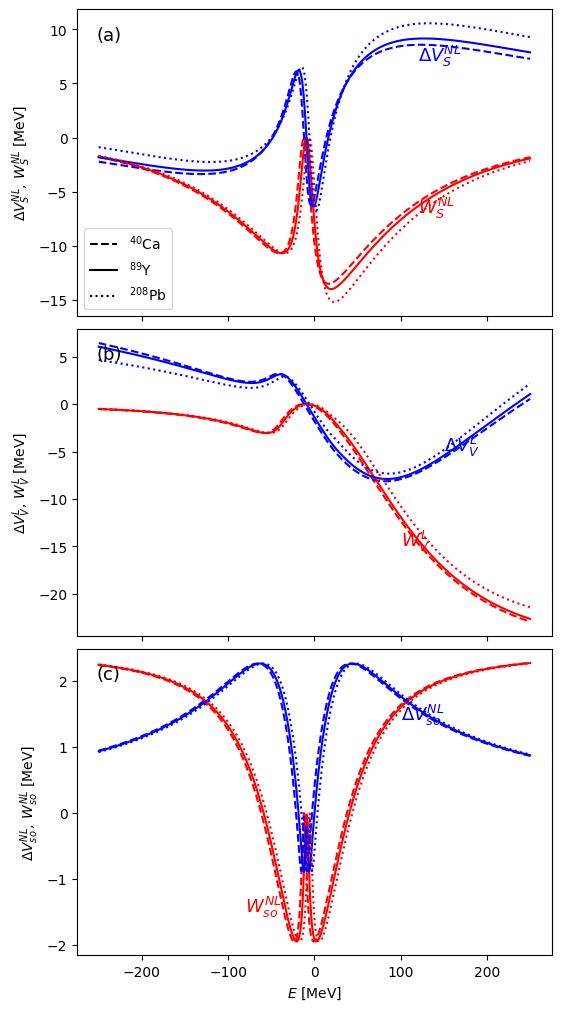

In [5]:
cases = [((40, 20), "dashed"), ((89, 39), "solid"), ((208, 82), "dotted")]
E_grid = np.linspace(-250.0, 250.0, 600)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(5.5, 10), sharex=True, constrained_layout=True
)
for (A, Z), style in cases:
    rxn = jitr.reactions.Reaction(target=(A, Z), projectile=neutron, process="EL")
    Ef = rxn.Ef
    c = mbra.resolve_coefficients(A)
    s_args = (c.AS_plus, c.AS_minus, c.BS, c.CS)
    v_args = (c.AV_plus, c.AV_minus, c.BV, c.EV_plus, c.EV_minus, c.ALPHA)
    so_args = (c.ASO, c.BSO, c.CSO, c.DSO)
    ax1.plot(E_grid, mbra.Ws_depth(E_grid, Ef, *s_args), color="r", ls=style)
    ax1.plot(E_grid, mbra.delta_Vs_depth(E_grid, Ef, *s_args), color="b", ls=style)
    ax2.plot(E_grid, mbra.Wv_depth(E_grid, Ef, *v_args), color="r", ls=style)
    ax2.plot(E_grid, mbra.delta_Vv_depth(E_grid, Ef, *v_args), color="b", ls=style)
    ax3.plot(E_grid, mbra.Wso_depth(E_grid, Ef, *so_args), color="r", ls=style)
    ax3.plot(E_grid, mbra.delta_Vso_depth(E_grid, Ef, *so_args), color="b", ls=style)

ax1.set_ylabel(r"$\Delta V_S^{NL},\, W_S^{NL}$ [MeV]")
ax1.annotate(r"$\Delta V_S^{NL}$", (120, 7), color="b", fontsize=13)
ax1.annotate(r"$W_S^{NL}$", (120, -7), color="r", fontsize=13)
ax2.set_ylabel(r"$\Delta V_V^{L},\, W_V^{L}$ [MeV]")
ax2.annotate(r"$\Delta V_V^{L}$", (150, -5), color="b", fontsize=13)
ax2.annotate(r"$W_V^{L}$", (100, -15), color="r", fontsize=13)
ax3.set_ylabel(r"$\Delta V_{so}^{NL},\, W_{so}^{NL}$ [MeV]")
ax3.annotate(r"$\Delta V_{so}^{NL}$", (100, 1.4), color="b", fontsize=13)
ax3.annotate(r"$W_{so}^{NL}$", (-80, -1.5), color="r", fontsize=13)
ax3.set_xlabel(r"$E$ [MeV]")
for ax, panel in zip((ax1, ax2, ax3), "abc", strict=True):
    ax.text(0.04, 0.9, f"({panel})", transform=ax.transAxes, fontsize=13)
names = (r"$^{40}$Ca", r"$^{89}$Y", r"$^{208}$Pb")
ax1.legend(
    handles=[
        Line2D([], [], color="k", ls=style, label=name)
        for ((A, Z), style), name in zip(cases, names, strict=True)
    ],
    loc="lower left",
);

## 3. Differential elastic cross sections (paper Fig. 6)

$n + {}^{208}$Pb at the two energies closest to the paper's $^{nat}$Pb
panels (14.23 and 9.87 MeV) with EXFOR data: 13.9 MeV and 9.97 MeV. One
energy-vectorized `DifferentialWorkspace` computes both energies in a single
solve.

In [6]:
import exfor_tools


def robust_query(rxn, quantity, Einc_range, disclude=("11848",)):
    """query_for_entries, discluding any entries that fail to parse."""
    disclude = list(disclude)
    while True:
        try:
            return exfor_tools.curate.query_for_entries(
                rxn, quantity=quantity, Einc_range=Einc_range, disclude=disclude
            )
        except Exception as e:  # noqa: BLE001 - parse errors carry the entry id
            msg = str(e)
            if "Entry:" in msg:
                disclude.append(msg.split("Entry:")[-1].strip())
            else:
                raise


exfor_rxn = exfor_tools.reaction.Reaction(
    target=target, projectile=neutron, process="El"
)
entries_da, _ = robust_query(exfor_rxn, "dXS/dA", [9.5, 15])
all_groups = exfor_tools.curate.categorize_measurements_by_energy(entries_da)
# the two energies closest to the paper's natPb panels (9.87 and 14.23 MeV)
groups = [
    min(all_groups, key=lambda g: abs(g[0].Einc - e_target))
    for e_target in (9.87, 14.23)
]
energies_da = [g[0].Einc for g in groups]
print("EXFOR dXS/dA energy groups [MeV]:", [round(e, 2) for e in energies_da])

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31


EXFOR dXS/dA energy groups [MeV]: [np.float64(9.97), np.float64(13.9)]


In [7]:
Elab_da = np.array(sorted(energies_da))
kin_da = reaction.kinematics(Elab_da)
R_FM = 15.0
angles = np.linspace(0.5, 179.5, 359) * np.pi / 180.0
lmax_da = jitr.xs.elastic.suggest_lmax(reaction, float(Elab_da[-1]), R_FM)

dws = jitr.xs.elastic.DifferentialWorkspace.build_from_system(
    reaction, kin_da, R_FM, lmax_da, angles, nbasis=50
)
V_da = mbra_interaction(dws.integral_workspace, reaction, kin_da)
xs_da = dws.xs(V_da)
dsdo = np.asarray(xs_da.dsdo)  # (N_E, N_theta), mb/sr

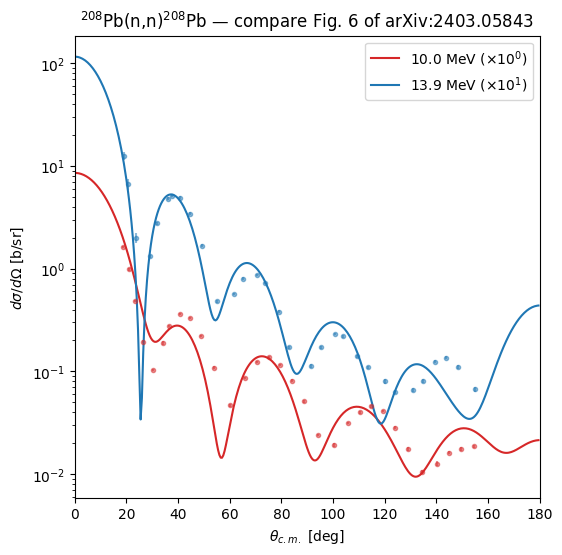

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
deg = angles * 180 / np.pi
colors = ("tab:red", "tab:blue")
groups_sorted = sorted(groups, key=lambda g: g[0].Einc)
for i, (Elab, group) in enumerate(zip(Elab_da, groups_sorted, strict=True)):
    offset = 10.0**i
    for m in group:
        # EXFOR dXS/dA comes back in b/sr
        ax.errorbar(
            m.x,
            offset * m.y,
            yerr=offset * m.statistical_err,
            ls="none",
            marker="o",
            markersize=3,
            color=colors[i],
            alpha=0.5,
        )
    ax.semilogy(
        deg,
        offset * dsdo[i] / 1000,
        color=colors[i],
        label=rf"{Elab:.1f} MeV ($\times 10^{{{i}}}$)",
    )
ax.set_xlabel(r"$\theta_{c.m.}$ [deg]")
ax.set_ylabel(r"$d\sigma/d\Omega$ [b/sr]")
ax.set_title(r"$^{208}$Pb(n,n)$^{208}$Pb — compare Fig. 6 of arXiv:2403.05843")
ax.legend()
ax.set_xlim([0, 180]);

## 4. Total cross section, 0.3–250 MeV (paper Fig. 5)

One energy-vectorized workspace per energy decade (so `lmax` can follow the
grazing angular momentum), each solving its whole grid in one call. EXFOR
$n + {}^{208}$Pb total cross sections overlaid.

In [9]:
exfor_tot_rxn = exfor_tools.reaction.Reaction(
    target=target, projectile=neutron, process="TOT"
)
entries_tot, _ = robust_query(exfor_tot_rxn, "XS", [0.3, 250])
E_tot_exp, xs_tot_exp = [], []
for entry in entries_tot.values():
    for m in entry.measurements:
        E_tot_exp.append(np.atleast_1d(m.x))  # MeV
        xs_tot_exp.append(np.atleast_1d(m.y))  # barns
E_tot_exp = np.concatenate(E_tot_exp)
xs_tot_exp = np.concatenate(xs_tot_exp)
print(f"{E_tot_exp.size} EXFOR total-xs points")

15793 EXFOR total-xs points


In [10]:
chunks = [
    (np.geomspace(0.3, 5.0, 20), 16),
    (np.geomspace(5.0, 50.0, 18), 32),
    (np.geomspace(50.0, 250.0, 14), None),  # lmax from suggest_lmax
]
E_model, sigt_model = [], []
for Elab_chunk, lmax in chunks:
    if lmax is None:
        lmax = jitr.xs.elastic.suggest_lmax(reaction, float(Elab_chunk[-1]), R_FM)
    kin = reaction.kinematics(Elab_chunk)
    ws = jitr.xs.elastic.IntegralWorkspace(
        reaction=reaction,
        kinematics=kin,
        channel_radius_fm=R_FM,
        nbasis=50,
        lmax=lmax,
    )
    V = mbra_interaction(ws, reaction, kin)
    sig_t, _ = ws.xs(V)
    E_model.append(Elab_chunk)
    sigt_model.append(np.asarray(sig_t))
E_model = np.concatenate(E_model)
sigt_model = np.concatenate(sigt_model)

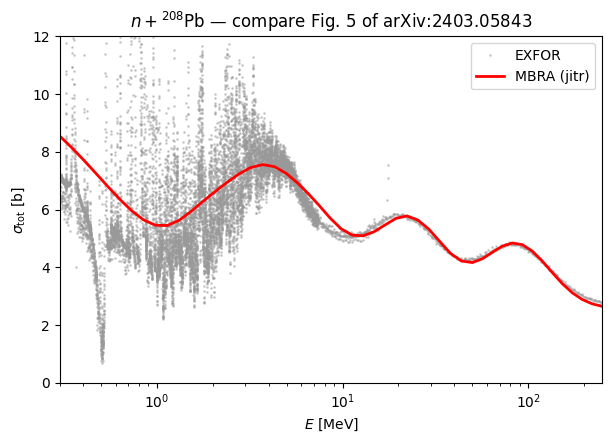

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(
    E_tot_exp,
    xs_tot_exp,
    ".",
    color="0.6",
    markersize=2,
    alpha=0.4,
    label="EXFOR",
    rasterized=True,
)
ax.semilogx(E_model, sigt_model / 1000, "r-", lw=2, label="MBRA (jitr)")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$\sigma_{\rm tot}$ [b]")
ax.set_title(r"$n + {}^{208}$Pb — compare Fig. 5 of arXiv:2403.05843")
ax.set_xlim([0.3, 250])
ax.set_ylim([0, 12])
ax.legend();

The model reproduces the Ramsauer oscillations of the averaged total cross
section over three decades of energy, and the diffraction pattern of the
differential cross sections — compare with Figs. 5 and 6 of the paper. Note
that below a few MeV the measured total cross section fluctuates with
compound-nucleus resonances; the optical model (and the paper's calibration)
describes the energy-averaged cross section there.